# Constructing Deviance Function
Deviance is a measure for how much a datapoint varies between observations. It may help us select which genomic coordinates are suitable to use for OT. Here, we'll work on implementing a function to calculate this.

## Imports

In [25]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
### Directories and Files ###
root = '../../../'
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files' # Importing was not working with relative root+'..' approach, so replace with local data
data_dir_immune = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'

In [44]:
### Imports ###
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, compile_hic_reads

In [39]:
### Importing coolers ###
clrs = import_cool_dir(data_dir)
clrs_immune = import_cool_dir(data_dir_immune)

## Main Function

In [31]:
def coordinate_deviance(compiled_reads: pd.DataFrame) -> pd.DataFrame:
    '''
        Takes compiled Hi-C data (cells in columns, coordinates in rows)
        and outputs a dataframe with deviance per genomic coordinate.

        Adapted from scry (https://github.com/kstreet13/scry)

        Parameters
        ----------
        compiled_reads : pd.DataFrame
            Compiled Hi-C data with cells in columns and coordinates
            in rows.
        
        Returns
        -------
        deviance : pd.DataFrame
            Dataframe describing deviance per genomic coordinate
    '''
    # Convert to numpy for faster calculations
    X = compiled_reads.to_numpy(dtype=np.float64)

    # Compute sums per cell
    sz = X.sum(axis=0)

    # Constructing saturated term
    P = X / sz

    logP = np.zeros_like(P)
    mask = P > 0
    logP[mask] = np.log(P[mask])

    log1P = np.log1p(-P)

    ll_sat = np.sum(
        X * logP + (sz - X) * log1P,
        axis=1
    )

    # Constructing null term
    sz_sum = np.sum(sz)
    feature_sums = X.sum(axis=1)

    p = feature_sums / sz_sum 
    
    logp = np.zeros_like(p)
    mask = p > 0
    logp[mask] = np.log(p[mask])

    log1p = np.log1p(-p)

    ll_null = feature_sums * logp + (sz_sum - feature_sums) * log1p

    # Compute deviance
    deviance_np = 2 * (ll_sat - ll_null)
    deviance_np[np.isnan(deviance_np)] = 0.0

    # Convert to dataframe
    deviance = pd.DataFrame(deviance_np, index=compiled_reads.index, columns=["deviances"])
    return deviance

## Testing

### Ramani

In [ ]:
### Compiling data ###
comp = compile_hic_reads(clrs, "chr1")

cell231_HAP1_  cell447_HAP1_  cell470_HAP1_  cell312_HAP1_  \
bin_i bin_j                                                               
0     0           1.028661       0.285375       0.312262       0.341930   
      1           0.753102       0.239738       0.315509       0.320945   
      2           0.726784       0.108721       0.119932       0.155017   
      3           0.632567       0.007453       0.003274       0.029000   
      4           0.442993       0.000398       0.000182       0.000479   
...                    ...            ...            ...            ...   
247   248         0.981592       0.637260       0.776159       0.720903   
      249         0.168058       0.020714       0.055638       0.028208   
248   248         1.921122       1.106228       1.271637       1.473078   
      249         0.173072       0.092492       0.091935       0.090360   
249   249         0.026762       0.007243       0.011108       0.011954   

             cell29_HAP1_  cell264_HAP1_  cell181_HeLa_  cell412_HAP1_  \
bin_i bin_j                                                              
0     0          0.861736       0.736400       0.670246       0.608400   
      1          0.668721       0.622554       0.562324       0.406955   
      2          0.619934       0.388824       0.472816       0.271594   
      3          0.553550       0.133087       0.359217       0.078112   
      4          0.289326       0.107370       0.218549       0.007543   
...                   ...            ...            ...            ...   
247   248        0.913622       0.885066       0.803893       0.875235   
      249        0.152153       0.157705       0.149175       0.159892   
248   248        1.800165       1.698459       1.553649       1.617354   
      249        0.179330       0.164042       0.156364       0.161262   
249   249        0.032087       0.025972       0.026075       0.016697   

             cell303_HeLa_  cell149_HeLa_  ...  cell112_HeLa_  cell36_HeLa_  \
bin_i bin_j                                ...                                
0     0           0.842762       0.721870  ...       0.643486      0.835233   
      1           0.640093       0.546353  ...       0.548589      0.435758   
      2           0.693362       0.264746  ...       0.378279      0.108883   
      3           0.608592       0.160327  ...       0.307503      0.066060   
      4           0.366758       0.036000  ...       0.115026      0.015304   
...                    ...            ...  ...            ...           ...   
247   248         0.909312       0.809091  ...       0.766412      0.704328   
      249         0.181240       0.160814  ...       0.143059      0.173037   
248   248         1.836289       1.593841  ...       1.503343      1.502313   
      249         0.198141       0.166016  ...       0.153389      0.178701   
249   249         0.035450       0.033401  ...       0.026703      0.029819   

             cell147_HeLa_  cell458_HeLa_  cell381_HAP1_  cell63_HeLa_  \
bin_i bin_j                                                              
0     0           0.709428       0.348329       0.685499      0.813366   
      1           0.618643       0.634908       0.424210      0.678678   
      2           0.508819       0.644894       0.107575      0.455684   
      3           0.291398       0.302878       0.006719      0.166363   
      4           0.090198       0.004904       0.002001      0.109213   
...                    ...            ...            ...           ...   
247   248         0.823853       0.829071       0.802316      0.909268   
      249         0.144177       0.147146       0.064241      0.181027   
248   248         1.590686       1.144733       1.619781      1.731761   
      249         0.157237       0.153270       0.103699      0.178153   
249   249         0.027928       0.008450       0.024464      0.034043   

             cell54_HeLa_  cell549_K562_  cell219_HeLa_  cell295_HAP1_  
bin_i bin_

In [32]:
### Calculating deviances ###
deviances = coordinate_deviance(comp)
deviances

deviances
bin_i bin_j           
0     0      31.909477
      1      21.508515
      2      66.676340
      3      94.574160
      4      94.386608
...                ...
247   248    42.829380
      249    10.194937
248   248    76.056890
      249     6.958970
249   249     0.666845

[31375 rows x 1 columns]

Text(0, 0.5, 'bin_i')

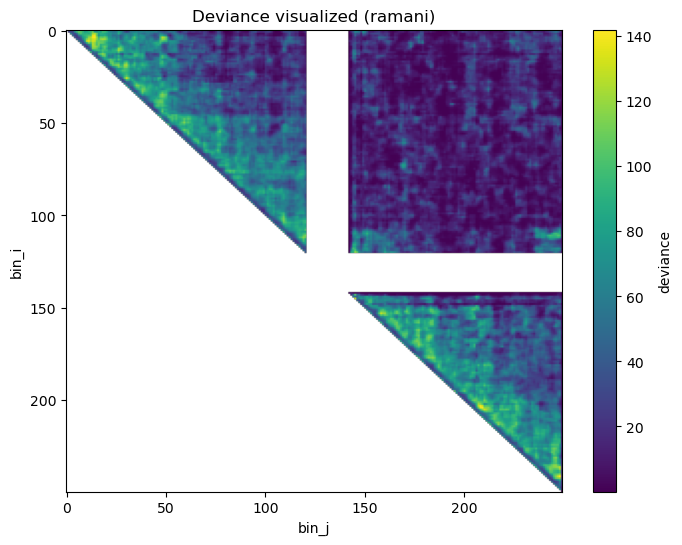

In [75]:
### Visualizing ###
heatmap_data = deviances['deviances'].unstack(level="bin_j")
plt.figure(figsize=(8,6))
plt.imshow(heatmap_data[heatmap_data > 0], origin='upper', cmap='viridis', aspect='auto')
plt.colorbar(label='deviance')
plt.title("Deviance visualized (ramani)")
plt.xlabel("bin_j")
plt.ylabel("bin_i")

array([[<Axes: title={'center': 'deviances'}>]], dtype=object)

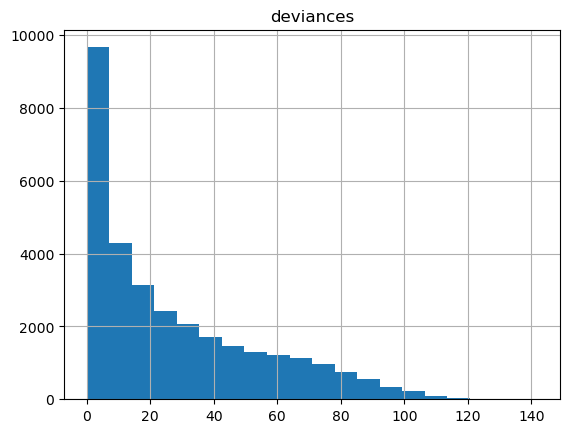

In [80]:
### Histogram ###
deviances.hist(bins=20)

The function does work. However, regrettably this kind of metric only works for non-normalized data. I'm not sure if this metric is sufficient for this kind of data structure.

### Immune

In [40]:
### Compiling data ###
comp_immune = compile_hic_reads(clrs_immune, "chr1")

In [65]:
### Calculating deviances ###
deviances_immune = coordinate_deviance(comp_immune)
deviances_immune

deviances
bin_i bin_j           
0     0       0.102264
      1      10.803060
      2       1.757726
      3       0.045123
      4       0.329472
...                ...
246   247    93.231206
      248     0.806947
247   247     1.380783
      248     3.165682
248   248     0.110746

[31125 rows x 1 columns]

Text(0, 0.5, 'bin_i')

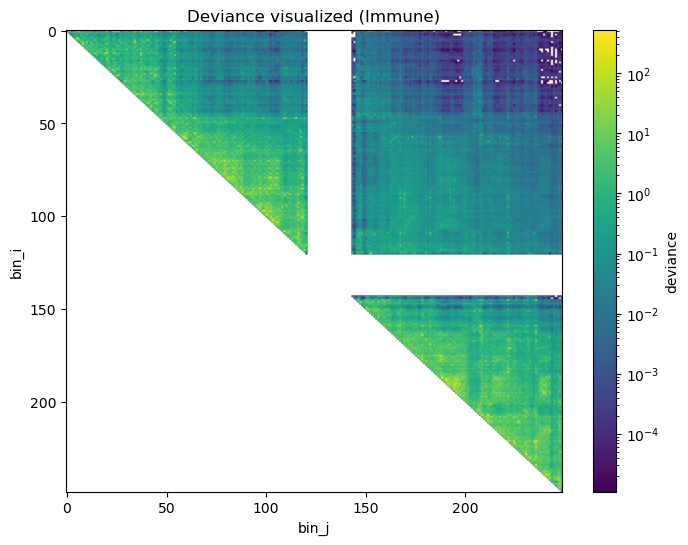

In [73]:
### Visualizing ###
heatmap_data_immune = deviances_immune['deviances'].unstack(level="bin_j")
heatmap_data_immune = heatmap_data_immune[heatmap_data_immune > 0]
plt.figure(figsize=(8,6))
plt.imshow(heatmap_data_immune, origin='upper', cmap='viridis', aspect='auto', norm=LogNorm(vmin=heatmap_data_immune.min().min(), vmax=heatmap_data_immune.max().max()))
plt.colorbar(label='deviance')
plt.title("Deviance visualized (Immune)")
plt.xlabel("bin_j")
plt.ylabel("bin_i")